povezave na učna gradiva:

https://www.geeksforgeeks.org/numpy-tutorial/


In [1]:
import numpy as np
#numpy array
#manipulacije z array (shape, reshape, ravel, traspose)
#boolovo indeksiranje
#broadcasting (soležni, s skalarjem na vektor ali matriko, z vektorjem na matriko)
#matematične funkcije

##D grafi, meshgrid


#reševanje sistemov linearnih enačb
import numpy.linalg as nlg

import sympy as sym
#nedoločen integral, odvod, limita
#v kombinaciji s sympy.diff (odvod in nato lambdify): poišči realno uporabo

import scypy as sp
#interpolacija
#kot nadgradnja linearne interpolacije v grafih
#curve fitting
#optimizacija

#učenje fukcij, da jih lahko potem uporabimo v scypy, numpy... (ne samo za klasično uporabo ponavljanja)


In [6]:
a = np.array([1, 2, 3, 4, 5 , 6])
a = a.reshape(2, 3)
a * 2
a * np.array([5, 1, 5])


array([[ 5,  2, 15],
       [20,  5, 30]])

In [2]:
#uvozimo vse potrebne knjižnice

import matplotlib.pyplot as plt  #risanje grafov
import numpy as np  #numerične metode
from sympy import *  #analitično računanje

import handcalcs.render  #izpis izpeljav

### Odvodi

Odvod v Pythonu lahko izračunamo numerično ali analitično. Za numerični izračun bomo uporabili knjižnico `numpy` za analitični izračun pa knjižnico `sympy`. 

### Numerični izračun

Vrednosti odvoda funkcije lahko izračunamo numerično, kadar poznamo funkcijski predpis ali kadar poznamo le funkcije vrednosti za določen nabor vrednosti neodvisne spremenljivke. 

Oba pristopa si poglejmo na primeru funkcije:

$f(x) = \dfrac{(x+4)}{\sqrt{(x^2+1)}}$

Predpostavimo najprej, da funkcijskega predpisa ne poznamo, vendar poznamo funkcijske vrednosti v določenih točkah. Na primer, za določene vrednosti neodvisne spremenljivke smo eksperimentalno izmerili vrednosti odvisne spremenljivke. Vrednosti neodvisne spremenljivke zapišimo v seznam `x`. Funkcijske vrednosti za vsak `x` prav tako zapišimo v seznam, in sicer seznam `y`. 

```
x = [-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.]

y = [-0.59702231, -0.55215763, -0.49613894, -0.42426407, -0.32879797,
        -0.19611614,  0.        ,  0.31622777,  0.89442719,  2.12132034,
         4.        ,  3.53553391,  2.68328157,  2.21359436,  1.940285  ,
         1.76504522,  1.64398987,  1.55563492,  1.48841682,  1.43560984,
         1.39305207]
```        

Sedaj pa izračunajmo odvod funkcije v točkah za katere poznamo funkcijsko vrednost.


In [4]:
#zapišemo funkcijo, uporabili jo bomo za oba primera
def f(x):
    return (x+4)/(x**2+1)**(1/2)


In [6]:
#pripravimo podatke za x in y
#predpostavimo, da smo te podatke pridobili iz meritev

x = np.linspace(-10, 10, 21)
y = f(x)
x,y

(array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.]),
 array([-0.59702231, -0.55215763, -0.49613894, -0.42426407, -0.32879797,
        -0.19611614,  0.        ,  0.31622777,  0.89442719,  2.12132034,
         4.        ,  3.53553391,  2.68328157,  2.21359436,  1.940285  ,
         1.76504522,  1.64398987,  1.55563492,  1.48841682,  1.43560984,
         1.39305207]))

Prikažimo vrednosti v grafu.

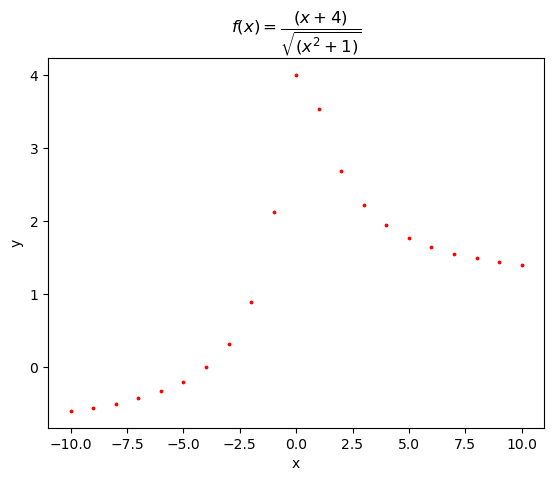

In [8]:
#pripravimo graf
fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('$f(x) = \dfrac{(x+4)}{\sqrt{(x^2+1)}}$');

#prikažemo vrednosti
ax.scatter(x, y, c='r', s=3);


Izračunamo vrednosti odvodov funkcije $f$ za vse vrednosti iz seznama `x`.

Za izračun uporabimo funkcijo `gradient` iz knjižnice `numpy`. 



In [11]:
y_prime = np.gradient(y, x[1]-x[0]) 

In [13]:
y_prime

array([ 0.04486468,  0.05044169,  0.06394678,  0.08367048,  0.11407397,
        0.16439899,  0.25617195,  0.4472136 ,  0.90254629,  1.5527864 ,
        0.70710678, -0.65835921, -0.66096977, -0.37149829, -0.22427457,
       -0.14814756, -0.10470515, -0.07778653, -0.06001254, -0.04768237,
       -0.04255777])

Prvi parameter funkcije `gradient` je nabor funkcijskih vrednosti funkcije $f$. 

Drugi parameter določa razmik med x vrednostmi. Privzeta vrednost razmika med vsemi zaporednimi vrednostmi x je 1, kar za naš primer velja. Vrednosti v seznamu namreč tečejo med -10 in 10 z razmikom 1. Tako v našem primeru drugega parametra ni bilo potrebno določiti. 

Če je vrednost različna od 1, pa jo moramo določiti, sicer vrednost odvodov ne bodo izračunane pravilno. To si bomo podrobneje pogledali na enem od naslednjih primerov. Lahko se tudi zgodi, da razmiki med x niso konstantni. V tem primeru namesto ene vrednosti kot drugi parameter podamo seznam vseh razmikov med x. 

V grafu prikažemo vrednosti odvodov v točkah `x`.

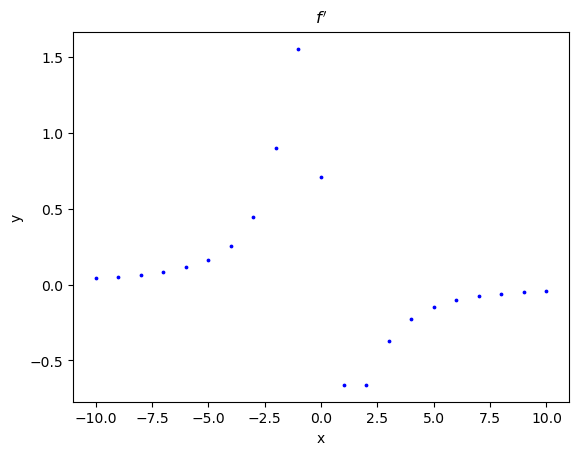

In [226]:
#pripravimo graf
fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('$f^\prime$');

#prikažemo vrednosti
ax.scatter(x, y_prime, c='b', s=3);

Če sedaj predpostavimo, da poznamo funkcijski predpis, lahko na enak način izračunamo odvod funkcije $f$ za poljubne vrednosti neodvisne spremenljivke $x$.

Najprej bomo pripravili seznam vseh vrednosti $x$, za katere želimo izračunati $f(x)$, ter nato izračunali še $f^\prime(x)$.

In [17]:
#pripravimo podatke za x in y
#ker poznamo f lahko y izračunamo poljubno gosto

x = np.linspace(-10, 10, 1000)  # interval razdelimo na 1000 korakov 
y = f(x)

y_prime = np.gradient(y, x[1]-x[0]) 


Funkcijo in njen odvod sedaj lahko tudi narišemo.

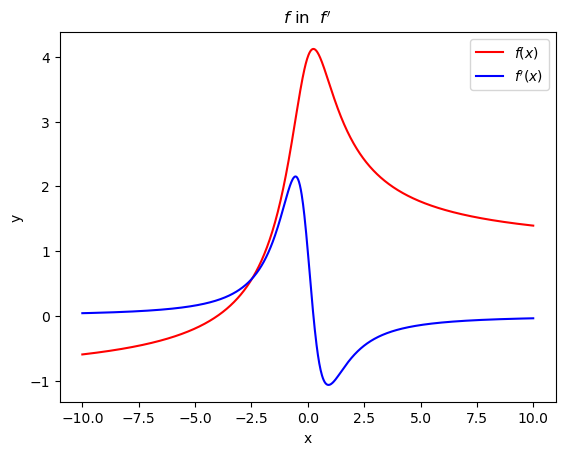

In [21]:
#pripravimo graf
fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('$f$ in  $f^\prime$');

#prikažemo vrednosti
ax.plot(x, y, c='r', label='$f(x)$');
ax.plot(x, y_prime, c='b', label='$f^\prime(x)$')
ax.legend();

### Analitični pristop

Python nam s knjižnico `sympy`, ki je algebraični sistem (Computer Algebraic System - CAS), omogoča odvod izračunati tudi analitično. Za to seveda moramo poznati funkcijski predpis. Za odvajanje uporabimo funkcijo `diff`.


In [25]:
from sympy import diff

#ustvarimo simbol x, uporabimo ime xx, ker smo x že uporabili kot seznam vrednosti spremenljvke x
simbol_x = symbols('x')

#obstoječo funkcijo f(x), ki je definirana zgoraj, odvajamo po x
df = diff(f(simbol_x), simbol_x)

df #izpišemo odvod funkcije


-1.0*x*(x + 4)/(x**2 + 1)**1.5 + (x**2 + 1)**(-0.5)

Ko poznamo $f^\prime$, lahko za vsak x izračunamo vrednost odvoda tako, da analitično funkcijo pretvorimo v običajno numerično funkcijo s pomočjo knjižnice `sympy`, in sicer tako, da pokličemo funkcijo `lambdify`. 

In [27]:
f_prime = lambdify(simbol_x, df)
y_prime = f_prime(x)

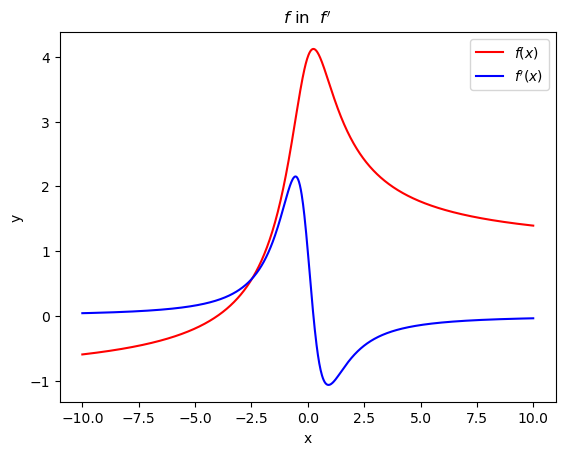

In [232]:
#pripravimo graf
fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('$f$ in  $f^\prime$');

#prikažemo vrednosti
ax.plot(x, y, c='r', label='$f(x)$');
ax.plot(x, y_prime, c='b', label='$f^\prime(x)$')
ax.legend();


In [146]:
#scipy  - mogoče tega ne bi niti pokazali, ker je depricated
'''
from scipy.misc import derivative

def dfdx(x):
    return derivative(f, x, 0.001)  #tretji param je dx

y_sp_prime = dfdx(x)

''';

### Primeri uporabe 

Ponovimo oba pristopa z odvajanjem funkcije:

$f(x) = \sqrt{\sin{x}}$

Za numerični izračun odvoda bomo potrebovali funkcijske vrednosti $f(x)$. Iz funkcijskega predpisa lahko vidimo, da funkcija ni realna za vsak $x$. Zato bomo za računanje odvoda uporabili samo nabor $x$, ki vrača realne vrednosti. V našem primeru bomo opazovali funkcijske vrednosti na intervalu [0, $\pi$].


In [262]:
x = np.linspace(0, np.pi, 180)

Interval smo razdelili na 180 delov tako, da je med posameznimi zaporednimi vredsnostmi $x$ vedno enaka razdalja.  

Sedaj izračunamo funkcijske vrednosti za vsak $x$.

In [263]:
y = np.sin(x)**(1/2)

Iz funkcijskih vrednosti izračunamo vrednosti odvodov v istih točkah. Odvoda bomo izračunali dvakrat, in sicer najprej tako, da bomo pustili privzeto vrednost razmika med $x$ (kar znaša 1). Nato bomo izračunali še enkrat, tako da bomo upoštevali dejanski razmik med $x$.

In [264]:
y_prime = np.gradient(y)  # napačne vrednosti, ker upošteva razdalje med točkami po x osi 1
y_prime_c = np.gradient(y, x[1]-x[0])  #korekcija razdalje med točkami po x osi

V grafu prikažemo vrednosti odvodov za oba primera.

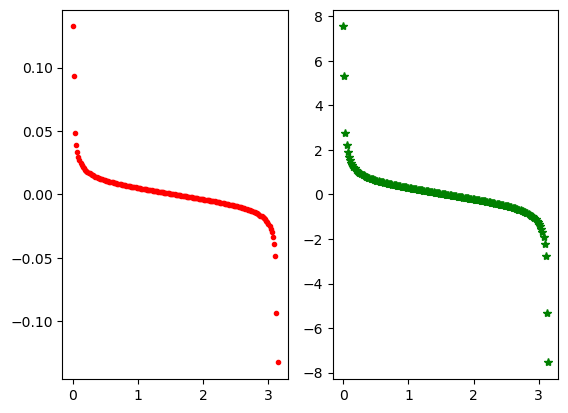

In [265]:
fig, ax = plt.subplots(1, 2)
ax[0].plot(x, y_prime, 'r.')
ax[1].plot(x, y_prime_c, 'g*');

Vidimo, da sta obliki funkcije $f^\prime$ v obeh primerih enaki, vendar če smo pozorni na os y, lahko vidimo, da se vrednosti pomembno razlikujejo. Pri izračunu odvoda s funkcijo `gradient` moramo vedno biti pozorni tudi na vrednosti $x$ iz katerih smo izračunali funkcijske vrednosti.

Sedaj pa izračunajmo odvod še analitično z uporabo knjižnice `sympy`.

In [266]:
#ustvarimo simbol x ter analitično funkcijo f(x)
x = symbols('x')
f = sin(x)**(1/2)

#odvajamo 
df = diff(f, x)

#rezultat odvajanja
df

0.5*cos(x)/sin(x)**0.5

Dobljeno funkcijo $f^\prime$ uporabimo za izračun vrednosti odvoda za izbrane vrednosti $x$. 
Zato analitično funkcijo pretvorimo v običajno numerično Python funkcijo.

In [267]:
f_prime = lambdify(x, df, 'numpy')

Pripravimo vhodne podatke za izračun v obliki seznama $x$ vrednosti.

In [268]:
x = np.linspace(0, np.pi, 180)

Izračunamo vrednosti  $f^\prime(x)$ za vse $x$ in dobimo seznam vrednosti odvoda za vsako podano vrednost $x$. Ker sta prva in zadnja vrednost odvoda izjemno veliki, morda celo neskončni, se odločimo, da bomo pri izračunu vrednosti 0 in $\pi$ (prva in zadnja vrednost $x$) izpustili.

In [269]:
y_prime_a = f_prime(x[1:-1])

Za konec še grafično prikažimo potek funkcije $f$ ter potek odvoda $f^\prime$ tako za numerično izračunan odvod, kakor za analitično izračunan odvod.  

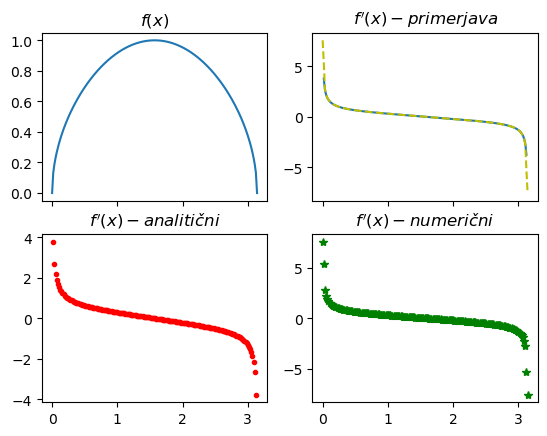

In [275]:

fig, ax = plt.subplots(2, 2, sharex = True)
ax[0,0].plot(x, y)
ax[0,0].set_title('$f(x)$')

ax[1,0].plot(x[1:-1], y_prime_a, 'r.')
ax[1,0].set_title('$f^\prime(x) - analitični$')

ax[1,1].plot(x, y_prime_c, 'g*')
ax[1,1].set_title('$f^\prime(x) - numerični$')

#primerjava numerične in analitične rešitve
ax[0,1].plot(x[1:-1], y_prime_a)
ax[0,1].plot(x, y_prime_c, 'y--')
ax[0,1].set_title('$f^\prime(x) - primerjava$');



In [98]:
t = 0.5 * np.cos(0)
u = np.sin(0)**(1/2)
t, u, t/u

C:\Users\Nenad\AppData\Local\Temp\ipykernel_10620\1251302907.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  t, u, t/u


(0.5, 0.0, inf)

### Integrali

$$\int_0^1\int_{-x}^{x^2} \sin(x + y^2)dx$$

In [7]:
import numpy as np
from scipy.integrate import dblquad

def integrand(x, y):
    return np.sin(x+y**2)

def meja_min(x):
    return -x

def meja_max(x):
    return x**2

integral, napaka = dblquad(integrand, 0, 1, meja_min, meja_max)

integral

0.315802507240474

In [282]:
x = symbols('x')
f = exp(-x**2)
y = integrate(f, (x, -oo, oo))
y

sqrt(pi)